<a href="https://colab.research.google.com/github/ashik7555-netizen/Python-Basics-Case-Study/blob/main/case_study_on_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier


In [4]:
data = pd.read_csv('/content/Training_data.csv')
data = pd.read_csv('/content/Testing_data.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [5]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
data.value_counts()

,,,,,,,,,,,,,,,,,,,,,count
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,
9975-SKRNR,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.90,18.9,No,1
9909-DFRJA,Female,0,No,No,26,Yes,No,Fiber optic,Yes,No,Yes,Yes,No,Yes,One year,Yes,Bank transfer (automatic),95.85,2475.35,No,1
9891-NQDBD,Female,0,Yes,No,28,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,25.55,672.2,No,1
9885-CSMWE,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,78.45,78.45,Yes,1
9878-TNQGW,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.95,171.15,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0030-FNXPP,Female,0,No,No,3,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.85,57.2,No,1
0022-TCJCI,Male,1,No,No,45,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Credit card (automatic),62.70,2791.5,Yes,1
0021-IKXGC,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,72.10,72.1,No,1


In [7]:
data.drop(columns = ['customerID'], inplace = True)
data = pd.get_dummies(data, columns = ['gender'], drop_first = True, dtype = int)
data.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Male
0,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No,1
1,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No,0
2,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes,1
3,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No,1
4,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No,0


In [8]:
y = data['Churn']
x = data.drop(columns = 'Churn')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 57)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(986, 19)
(423, 19)
(986,)
(423,)


In [9]:
x_train_processed = x_train.copy()
x_test_processed = x_test.copy()
x_train_processed['TotalCharges'] = pd.to_numeric(x_train_processed['TotalCharges'], errors='coerce').fillna(0)
x_test_processed['TotalCharges'] = pd.to_numeric(x_test_processed['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in x_train_processed.columns:
    x_train_processed.drop(columns=['customerID'], inplace=True)
if 'customerID' in x_test_processed.columns:
    x_test_processed.drop(columns=['customerID'], inplace=True)
categorical_cols = x_train_processed.select_dtypes(include='object').columns.tolist()
x_train_processed = pd.get_dummies(x_train_processed, columns=categorical_cols, drop_first=True, dtype=int)
x_test_processed = pd.get_dummies(x_test_processed, columns=categorical_cols, drop_first=True, dtype=int)
train_cols = x_train_processed.columns
test_cols = x_test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    x_test_processed[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    x_train_processed[c] = 0

x_test_processed = x_test_processed[train_cols]
std_scalar = StandardScaler()

x_train_processed[train_cols] = std_scalar.fit_transform(x_train_processed[train_cols])
x_test_processed[train_cols] = std_scalar.transform(x_test_processed[train_cols])
x_train = x_train_processed
x_test = x_test_processed

x_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
580,-0.456435,0.838675,-1.319466,-0.451965,0.973970,1.045666,1.497805,0.332205,-0.332205,1.170552,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,1.758205
1251,-0.456435,-1.155309,-1.304484,-0.966047,-1.026726,-0.956328,-0.667643,-3.010187,3.010187,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,-0.517061,1.413139,-0.568762
741,-0.456435,0.960756,-1.500916,-0.485287,0.973970,1.045666,1.497805,0.332205,-0.332205,-0.854298,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,-0.568762
332,-0.456435,-1.155309,-0.508768,-0.917657,0.973970,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,0.841926,-0.517061,1.413139,-0.568762
678,-0.456435,-1.155309,0.521667,-0.896351,-1.026726,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,1.934007,-0.707645,-0.568762


In [42]:
log_model2 = LogisticRegression()
y_train_processed = y_train.map({'Yes': 1, 'No': 0})
y_test_processed = y_test.map({'Yes': 1, 'No': 0})

log_model2.fit(x_train, y_train_processed)
y_pred = log_model2.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In [11]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test_processed, y_pred)

0.0

/tmp/ipykernel_3518/2868208391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_processed, palette='viridis')


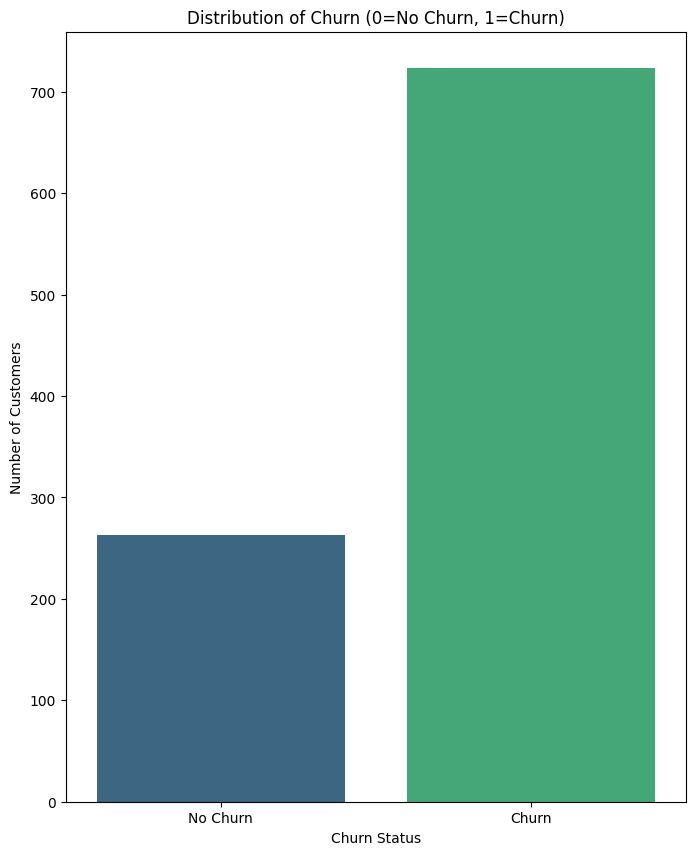

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 10))
sns.countplot(x=y_train_processed, palette='viridis')
plt.title('Distribution of Churn (0=No Churn, 1=Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

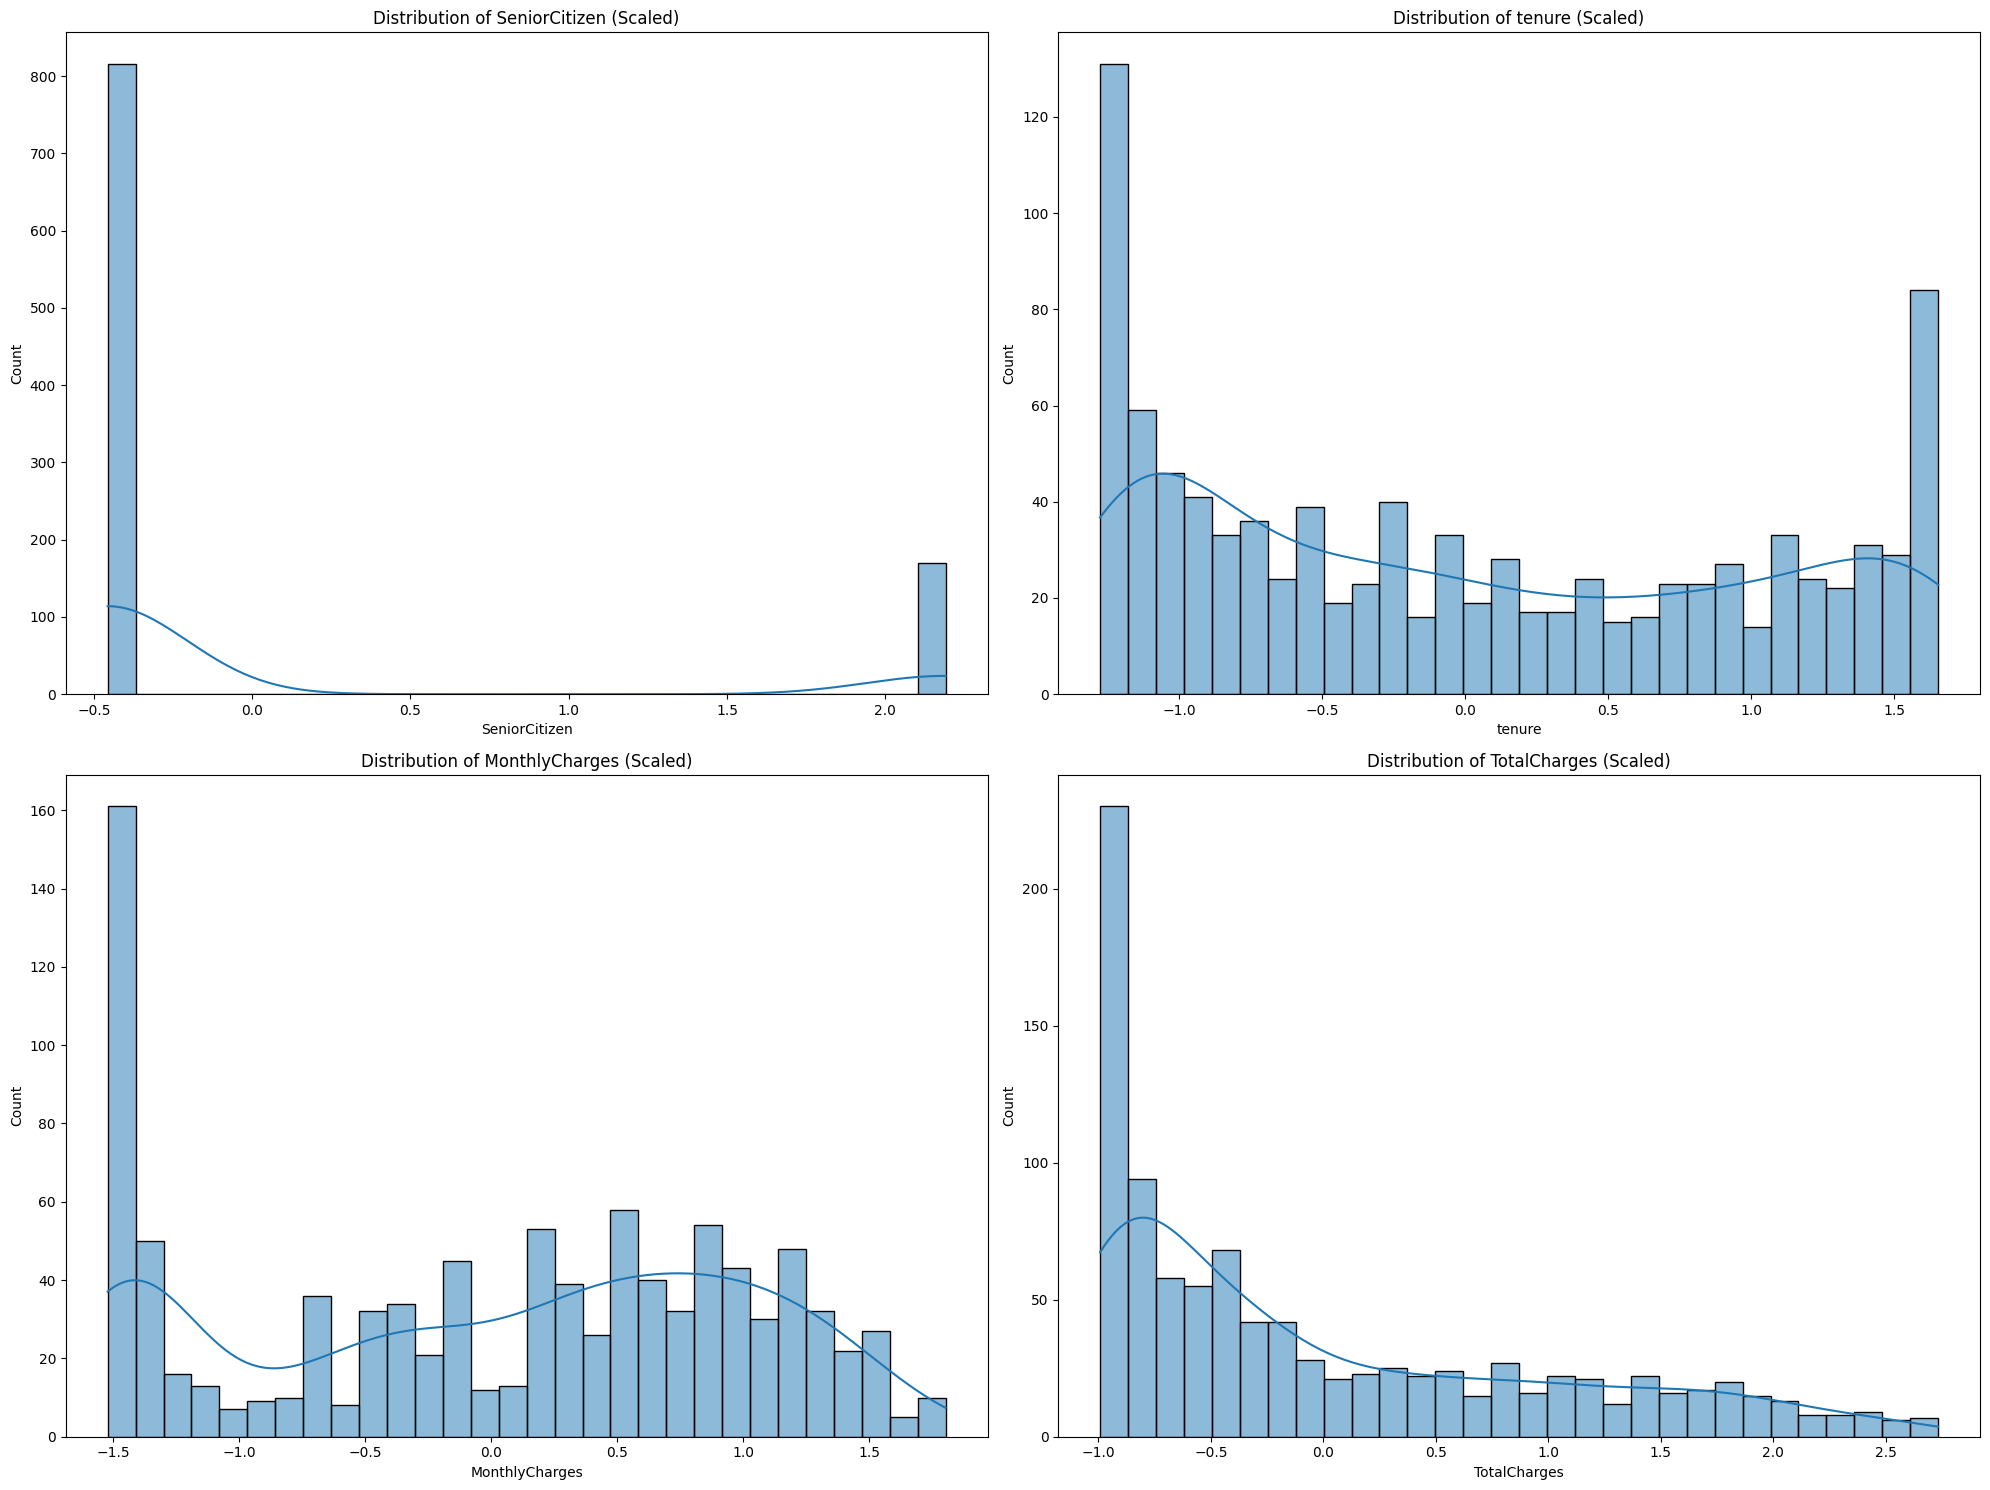

In [13]:
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(x_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Scaled)')
plt.tight_layout()
plt.show()

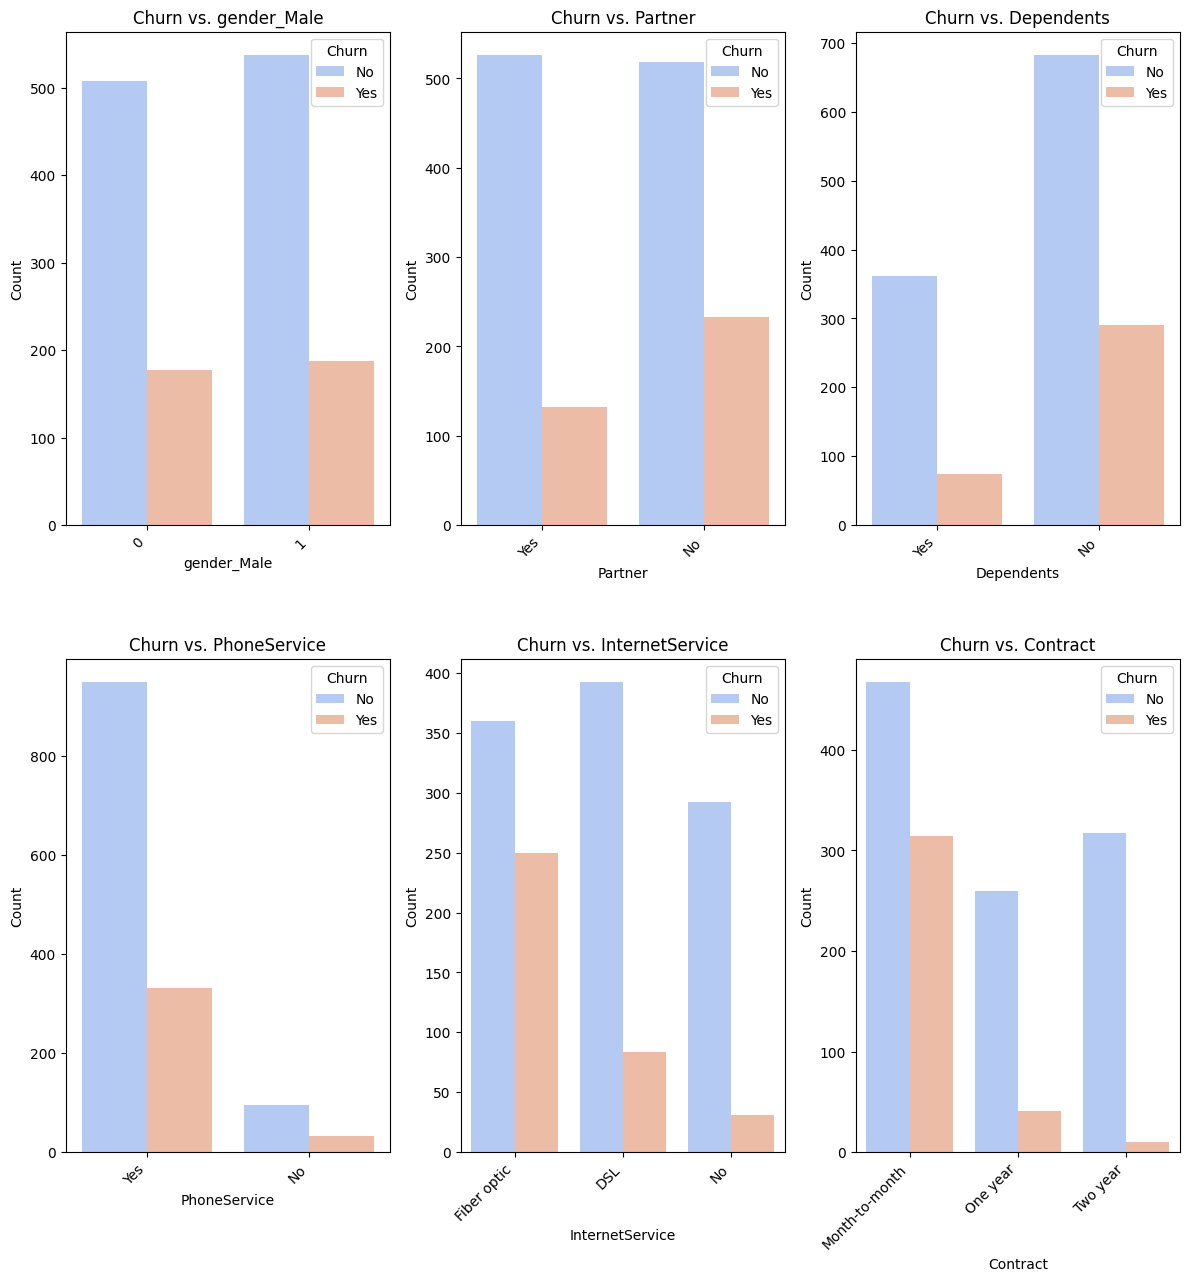

In [18]:
combined_df = x.copy()
combined_df['Churn'] = y.copy()

original_categorical_display_cols = ['gender_Male', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract']

plt.figure(figsize=(12, 18))
for i, col in enumerate(original_categorical_display_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue='Churn', data=combined_df, palette='coolwarm')
    plt.title(f'Churn vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
print('Descriptive Statistics for Scaled Numerical Features in x_train:')
display(x_train[numerical_features].describe())

Descriptive Statistics for Scaled Numerical Features in x_train:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,9.860000e+02,9.860000e+02,9.860000e+02,9.860000e+02
mean,-6.846000e-17,5.179539e-17,-2.161895e-17,-1.423247e-16
std,1.000507e+00,1.000507e+00,1.000507e+00,1.000507e+00
min,-4.564355e-01,-1.277390e+00,-1.522556e+00,-9.919228e-01
25%,-4.564355e-01,-9.518415e-01,-9.740453e-01,-8.354345e-01
50%,-4.564355e-01,-1.786638e-01,1.845698e-01,-3.894727e-01
75%,-4.564355e-01,9.505828e-01,8.362908e-01,6.888180e-01
max,2.190890e+00,1.652547e+00,1.803468e+00,2.732430e+00


/tmp/ipykernel_3518/1404792361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=x_train[col], palette='viridis')
/tmp/ipykernel_3518/1404792361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=x_train[col], palette='viridis')
/tmp/ipykernel_3518/1404792361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=x_train[col], palette='viridis')
/tmp/ipykernel_3518/1404792361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fa

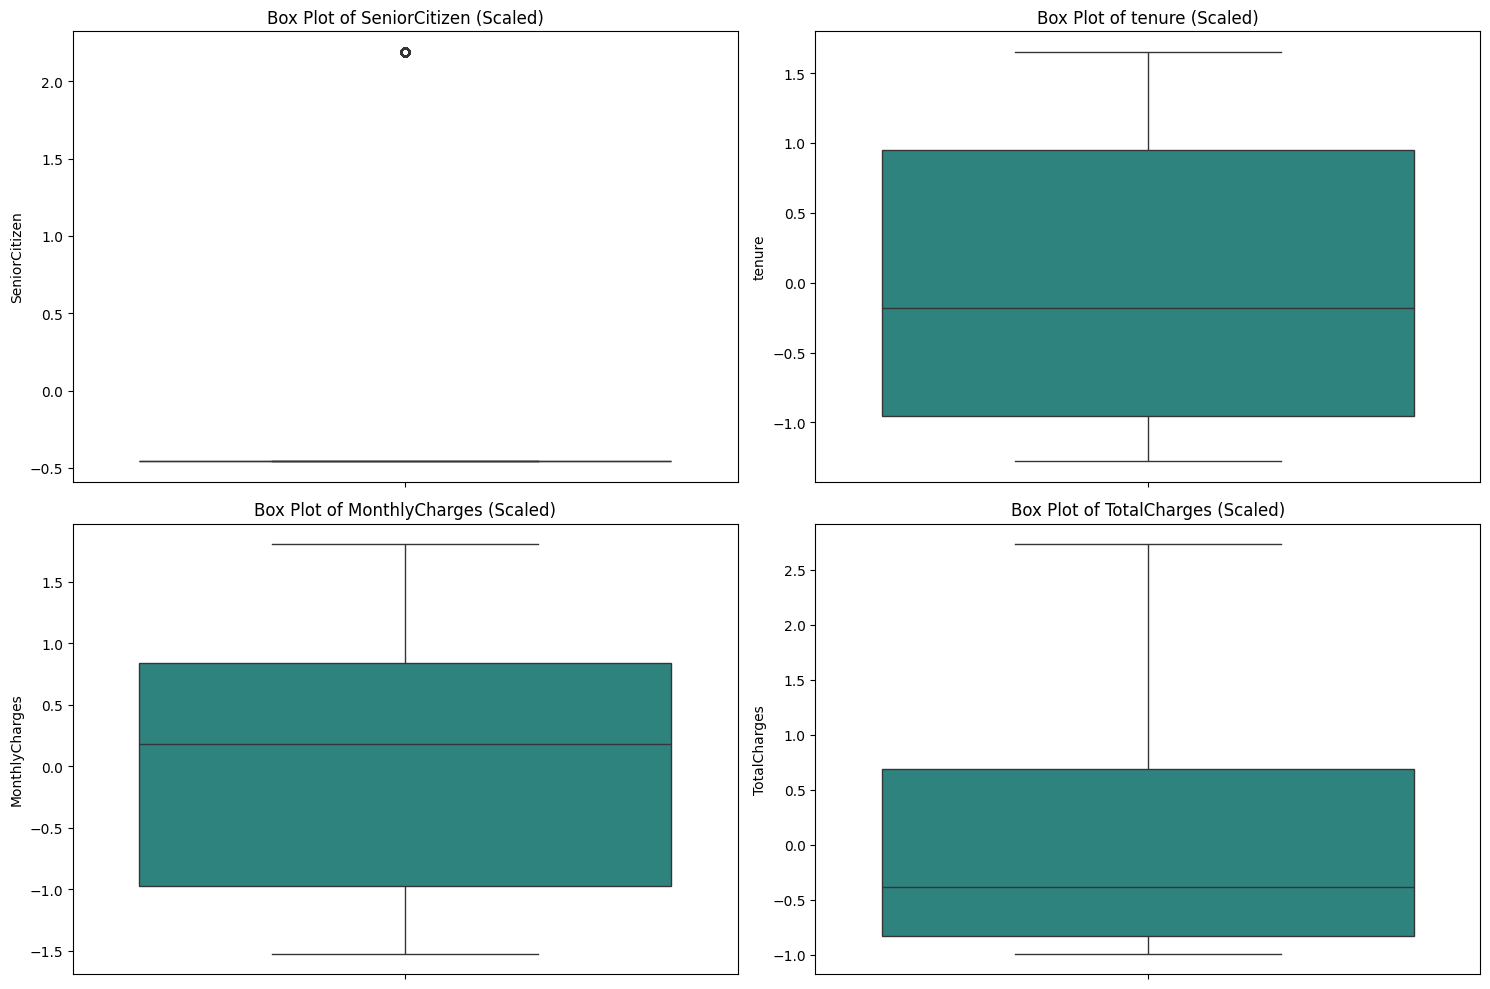

In [20]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=x_train[col], palette='viridis')
    plt.title(f'Box Plot of {col} (Scaled)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

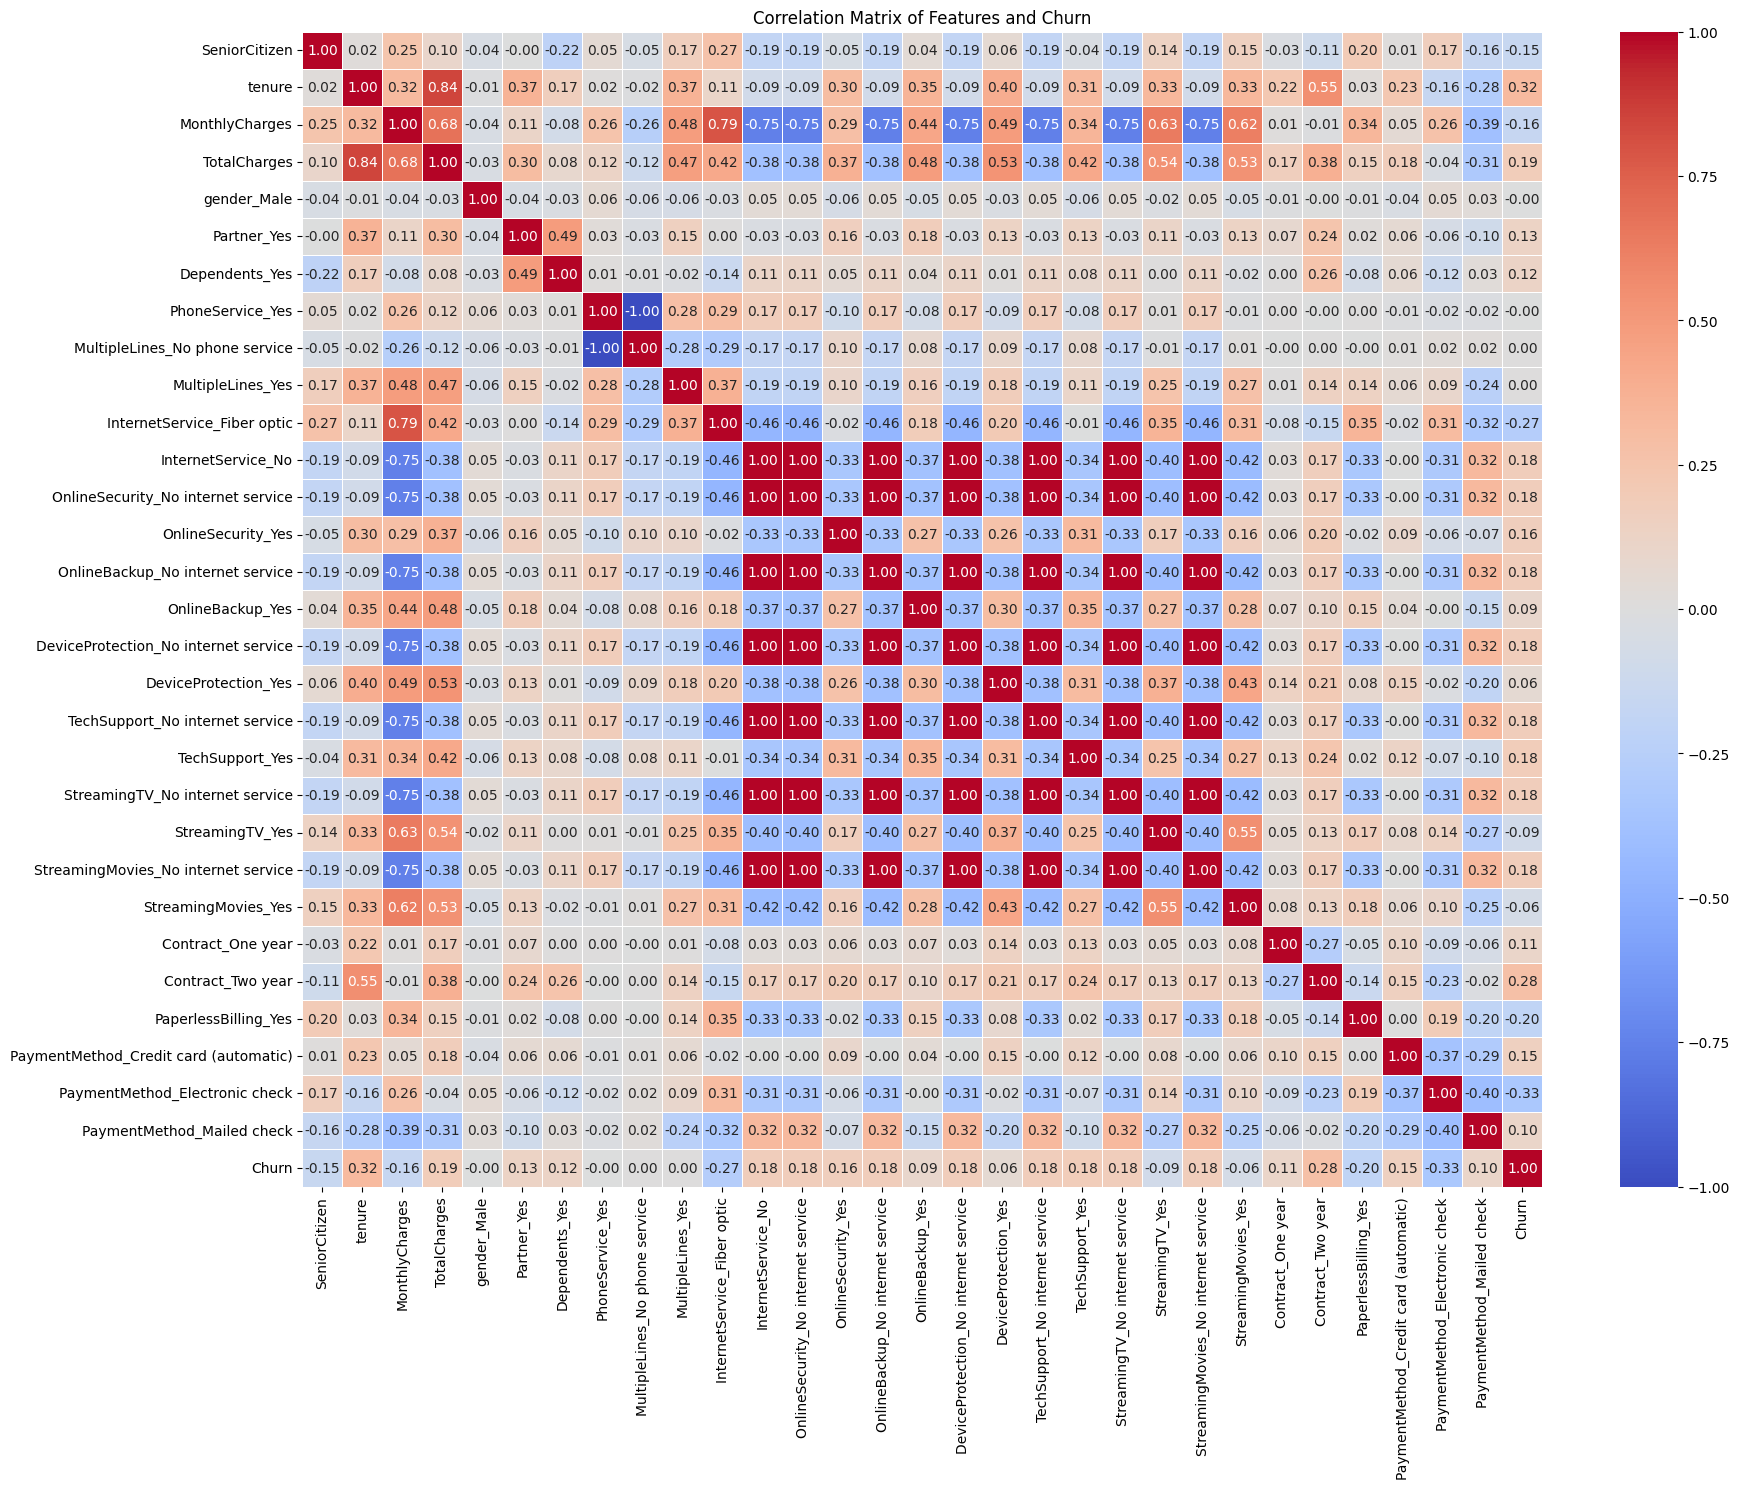

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_df = x_train.copy()
correlation_df['Churn'] = y_train_processed
corr_matrix = correlation_df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features and Churn')
plt.show()

In [22]:
data_initial = pd.read_csv('/content/Testing_data.csv')
display(data_initial.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [23]:
data_total_charges_prep = data_initial.copy()
print('Original TotalCharges dtype:', data_total_charges_prep['TotalCharges'].dtype)
print('Original TotalCharges unique values (sample):', data_total_charges_prep['TotalCharges'].unique()[:5])
data_total_charges_prep['TotalCharges'] = pd.to_numeric(data_total_charges_prep['TotalCharges'], errors='coerce').fillna(0)

print('\nTotalCharges dtype after conversion and fillna:', data_total_charges_prep['TotalCharges'].dtype)
print('TotalCharges values after conversion and fillna (sample):', data_total_charges_prep['TotalCharges'].head())

Original TotalCharges dtype: object
Original TotalCharges unique values (sample): ['3292.3' '876.75' '4211.55' '8547.15' '374']

TotalCharges dtype after conversion and fillna: float64
TotalCharges values after conversion and fillna (sample): 0    3292.30
1     876.75
2    4211.55
3    8547.15
4     374.00
Name: TotalCharges, dtype: float64


In [24]:
data_after_id_drop = data_initial.drop(columns=['customerID']).copy()
display(data_after_id_drop.head())
print(f"'customerID' column exists: {'customerID' in data_after_id_drop.columns}")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,Male,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,Female,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


'customerID' column exists: False


In [25]:
data_after_gender_encode = data_after_id_drop.copy()
data_after_gender_encode = pd.get_dummies(data_after_gender_encode, columns = ['gender'], drop_first = True, dtype = int)
display(data_after_gender_encode.head())

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Male
0,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No,1
1,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No,0
2,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes,1
3,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No,1
4,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No,0


In [26]:
print('x_train.head() after initial split and customerID/gender handling:')
display(x_train.head())

x_train.head() after initial split and customerID/gender handling:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
580,-0.456435,0.838675,-1.319466,-0.451965,0.973970,1.045666,1.497805,0.332205,-0.332205,1.170552,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,1.758205
1251,-0.456435,-1.155309,-1.304484,-0.966047,-1.026726,-0.956328,-0.667643,-3.010187,3.010187,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,-0.517061,1.413139,-0.568762
741,-0.456435,0.960756,-1.500916,-0.485287,0.973970,1.045666,1.497805,0.332205,-0.332205,-0.854298,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,-0.568762
332,-0.456435,-1.155309,-0.508768,-0.917657,0.973970,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,0.841926,-0.517061,1.413139,-0.568762
678,-0.456435,-1.155309,0.521667,-0.896351,-1.026726,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,1.934007,-0.707645,-0.568762


In [27]:
print('x_train.head() after all preprocessing (encoding and scaling):')
display(x_train.head())

x_train.head() after all preprocessing (encoding and scaling):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
580,-0.456435,0.838675,-1.319466,-0.451965,0.973970,1.045666,1.497805,0.332205,-0.332205,1.170552,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,1.758205
1251,-0.456435,-1.155309,-1.304484,-0.966047,-1.026726,-0.956328,-0.667643,-3.010187,3.010187,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,-0.517061,1.413139,-0.568762
741,-0.456435,0.960756,-1.500916,-0.485287,0.973970,1.045666,1.497805,0.332205,-0.332205,-0.854298,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,-0.568762
332,-0.456435,-1.155309,-0.508768,-0.917657,0.973970,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,0.841926,-0.517061,1.413139,-0.568762
678,-0.456435,-1.155309,0.521667,-0.896351,-1.026726,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,1.934007,-0.707645,-0.568762


In [28]:
print('y_train_processed.head():')
display(y_train_processed.head())

y_train_processed.head():


,Churn
580,4
1251,2
741,4
332,2
678,2



Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     321.0
           2       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00     102.0

    accuracy                           0.00     423.0
   macro avg       0.00      0.00      0.00     423.0
weighted avg       0.00      0.00      0.00     423.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

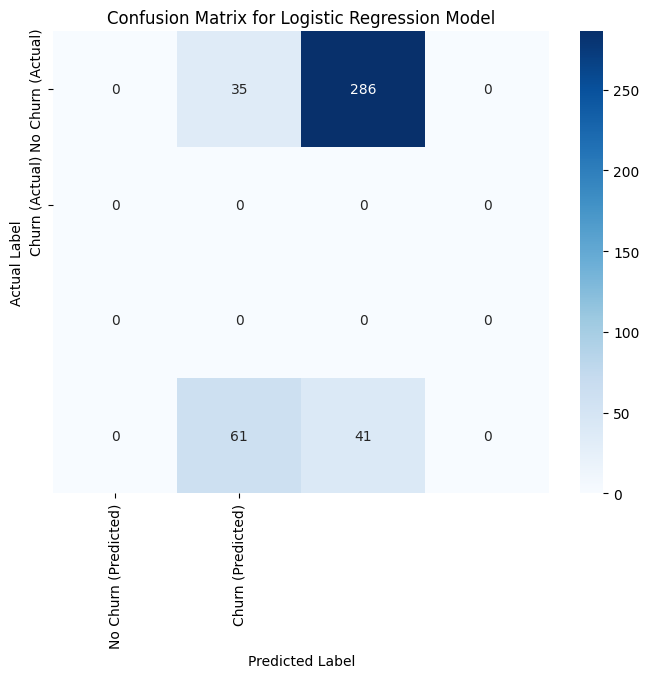

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred))
conf_matrix = confusion_matrix(y_test_processed, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [30]:
x_train_fe = x_train.copy()
x_test_fe = x_test.copy()

print("Shape of x_train_fe before new features:", x_train_fe.shape)
print("Shape of x_test_fe before new features:", x_test_fe.shape)
print('\nx_train_fe head:')
display(x_train_fe.head())

Shape of x_train_fe before new features: (986, 30)
Shape of x_test_fe before new features: (423, 30)

x_train_fe head:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
580,-0.456435,0.838675,-1.319466,-0.451965,0.973970,1.045666,1.497805,0.332205,-0.332205,1.170552,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,1.758205
1251,-0.456435,-1.155309,-1.304484,-0.966047,-1.026726,-0.956328,-0.667643,-3.010187,3.010187,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,-0.517061,1.413139,-0.568762
741,-0.456435,0.960756,-1.500916,-0.485287,0.973970,1.045666,1.497805,0.332205,-0.332205,-0.854298,...,1.910744,-0.76499,1.910744,-0.793569,-0.512332,1.888072,-1.187753,-0.517061,-0.707645,-0.568762
332,-0.456435,-1.155309,-0.508768,-0.917657,0.973970,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,0.841926,-0.517061,1.413139,-0.568762
678,-0.456435,-1.155309,0.521667,-0.896351,-1.026726,-0.956328,-0.667643,0.332205,-0.332205,-0.854298,...,-0.523356,-0.76499,-0.523356,-0.793569,-0.512332,-0.529641,-1.187753,1.934007,-0.707645,-0.568762


In [31]:
x_train_fe['Tenure_x_Contract'] = x_train_fe['tenure'] * x_train_fe['Contract_Two year']
x_test_fe['Tenure_x_Contract'] = x_test_fe['tenure'] * x_test_fe['Contract_Two year']

print('\nx_train_fe head with new Tenure_x_Contract feature:')
display(x_train_fe[['tenure', 'Contract_Two year', 'Tenure_x_Contract']].head())


x_train_fe head with new Tenure_x_Contract feature:


,tenure,Contract_Two year,Tenure_x_Contract
580,0.838675,1.888072,1.583479
1251,-1.155309,-0.529641,0.611899
741,0.960756,1.888072,1.813977
332,-1.155309,-0.529641,0.611899
678,-1.155309,-0.529641,0.611899


In [32]:
x_train_fe['Tenure_x_MonthlyCharges'] = x_train_fe['tenure'] * x_train_fe['MonthlyCharges']
x_test_fe['Tenure_x_MonthlyCharges'] = x_test_fe['tenure'] * x_test_fe['MonthlyCharges']

print('\nx_train_fe head with new Tenure_x_MonthlyCharges feature:')
display(x_train_fe[['tenure', 'MonthlyCharges', 'Tenure_x_MonthlyCharges']].head())


x_train_fe head with new Tenure_x_MonthlyCharges feature:


,tenure,MonthlyCharges,Tenure_x_MonthlyCharges
580,0.838675,-1.319466,-1.106604
1251,-1.155309,-1.304484,1.507082
741,0.960756,-1.500916,-1.442014
332,-1.155309,-0.508768,0.587785
678,-1.155309,0.521667,-0.602687


In [34]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=57)
rf_model.fit(x_train_fe, y_train_processed)
feature_importances = pd.Series(rf_model.feature_importances_, index=x_train_fe.columns)
print('\nTop 10 Feature Importances:')
display(feature_importances.nlargest(10))


Top 10 Feature Importances:


,0
TotalCharges,0.131681
Tenure_x_MonthlyCharges,0.129610
MonthlyCharges,0.127799
tenure,0.107229
Tenure_x_Contract,0.094681
PaymentMethod_Electronic check,0.052751
InternetService_Fiber optic,0.034788
PaperlessBilling_Yes,0.026561
OnlineSecurity_Yes,0.024617
gender_Male,0.024329


In [35]:
selected_features = feature_importances.nlargest(15).index.tolist()

x_train_selected = x_train_fe[selected_features]
x_test_selected = x_test_fe[selected_features]

print('\nShape of x_train_selected:', x_train_selected.shape)
print('\nx_train_selected head:')
display(x_train_selected.head())


Shape of x_train_selected: (986, 15)

x_train_selected head:


,TotalCharges,Tenure_x_MonthlyCharges,MonthlyCharges,tenure,Tenure_x_Contract,PaymentMethod_Electronic check,InternetService_Fiber optic,PaperlessBilling_Yes,OnlineSecurity_Yes,gender_Male,Contract_Two year,Partner_Yes,TechSupport_Yes,StreamingTV_Yes,Dependents_Yes
580,-0.451965,-1.106604,-1.319466,0.838675,1.583479,-0.707645,-0.877609,-1.187753,-0.634477,0.973970,1.888072,1.045666,-0.645497,-0.76499,1.497805
1251,-0.966047,1.507082,-1.304484,-1.155309,0.611899,1.413139,-0.877609,-1.187753,-0.634477,-1.026726,-0.529641,-0.956328,-0.645497,-0.76499,-0.667643
741,-0.485287,-1.442014,-1.500916,0.960756,1.813977,-0.707645,-0.877609,-1.187753,-0.634477,0.973970,1.888072,1.045666,-0.645497,-0.76499,1.497805
332,-0.917657,0.587785,-0.508768,-1.155309,0.611899,1.413139,-0.877609,0.841926,-0.634477,0.973970,-0.529641,-0.956328,-0.645497,-0.76499,-0.667643
678,-0.896351,-0.602687,0.521667,-1.155309,0.611899,-0.707645,1.139460,-1.187753,-0.634477,-1.026726,-0.529641,-0.956328,1.549193,-0.76499,-0.667643



--- Logistic Regression Model Evaluation (with FE & Selected Features) ---
Accuracy: 0.8014

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       321
           1       0.60      0.53      0.56       102

    accuracy                           0.80       423
   macro avg       0.73      0.71      0.72       423
weighted avg       0.79      0.80      0.80       423



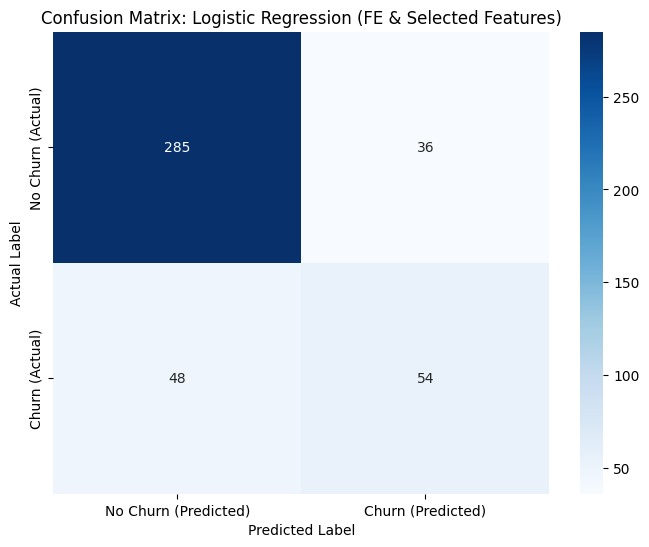

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
log_model_fe = LogisticRegression(random_state=57, solver='liblinear')
log_model_fe.fit(x_train_selected, y_train_processed) # Retrain with corrected y_train_processed
y_pred_log_fe = log_model_fe.predict(x_test_selected) # Regenerate predictions
print("\n--- Logistic Regression Model Evaluation (with FE & Selected Features) ---")
print(f"Accuracy: {accuracy_score(y_test_processed, y_pred_log_fe):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_log_fe))
conf_matrix_log_fe = confusion_matrix(y_test_processed, y_pred_log_fe)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_fe, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix: Logistic Regression (FE & Selected Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


--- Random Forest Classifier Evaluation (with FE & Selected Features) ---
Accuracy: 0.7967

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       321
           1       0.59      0.53      0.56       102

    accuracy                           0.80       423
   macro avg       0.72      0.71      0.71       423
weighted avg       0.79      0.80      0.79       423



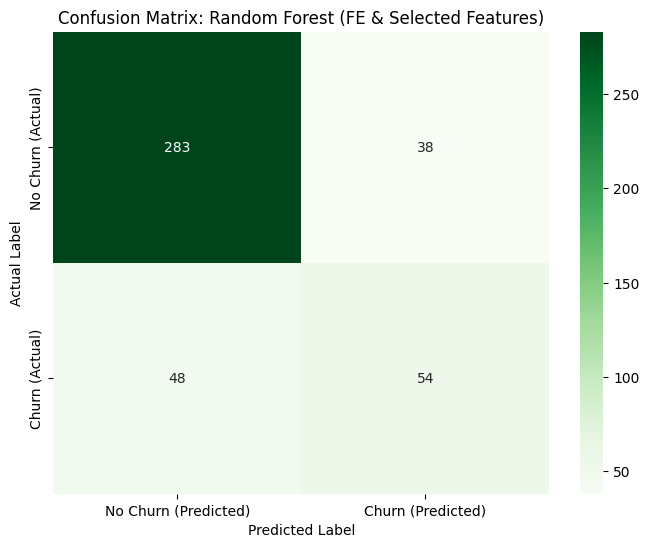

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_model_fe = RandomForestClassifier(random_state=57, n_estimators=100)
rf_model_fe.fit(x_train_selected, y_train_processed) # Retrain with corrected y_train_processed
y_pred_rf_fe = rf_model_fe.predict(x_test_selected) # Regenerate predictions

print("\n--- Random Forest Classifier Evaluation (with FE & Selected Features) ---")
print(f"Accuracy: {accuracy_score(y_test_processed, y_pred_rf_fe):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_rf_fe))

conf_matrix_rf_fe = confusion_matrix(y_test_processed, y_pred_rf_fe)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_fe, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix: Random Forest (FE & Selected Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


--- Gradient Boosting Classifier Evaluation (with FE & Selected Features) ---
Accuracy: 0.7920

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       321
           1       0.58      0.51      0.54       102

    accuracy                           0.79       423
   macro avg       0.71      0.70      0.70       423
weighted avg       0.78      0.79      0.79       423



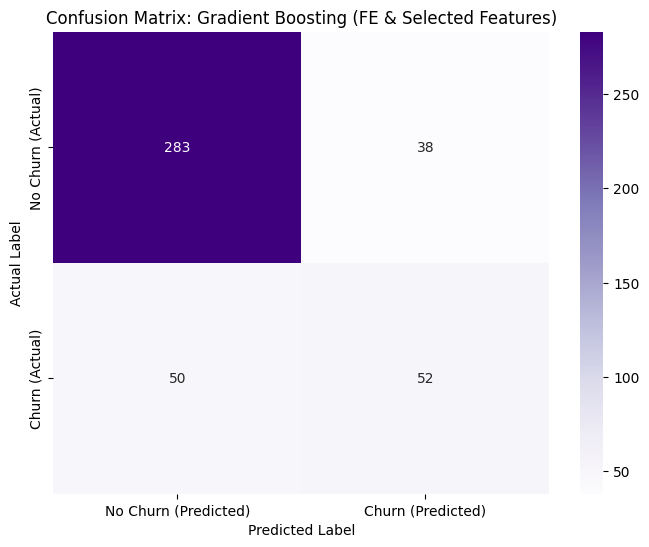

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model_fe = GradientBoostingClassifier(random_state=57, n_estimators=100, learning_rate=0.1)
gbc_model_fe.fit(x_train_selected, y_train_processed)

y_pred_gbc_fe = gbc_model_fe.predict(x_test_selected)

print("\n--- Gradient Boosting Classifier Evaluation (with FE & Selected Features) ---")
print(f"Accuracy: {accuracy_score(y_test_processed, y_pred_gbc_fe):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_gbc_fe))

conf_matrix_gbc_fe = confusion_matrix(y_test_processed, y_pred_gbc_fe)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gbc_fe, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix: Gradient Boosting (FE & Selected Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [52]:
from sklearn.metrics import recall_score, f1_score, accuracy_score
import pandas as pd

model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
predictions = [y_pred_log_fe, y_pred_rf_fe, y_pred_gbc_fe]

results = {
    'Model': [],
    'Accuracy': [],
    'Recall (Churn)': [],
    'F1-Score (Churn)': []
}

for i, model_name in enumerate(model_names):
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy_score(y_test_processed, predictions[i]))


    results['Recall (Churn)'].append(recall_score(y_test_processed, predictions[i], pos_label=1))
    results['F1-Score (Churn)'].append(f1_score(y_test_processed, predictions[i], pos_label=1))

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score (Churn)', ascending=False))

,Model,Accuracy,Recall (Churn),F1-Score (Churn)
0,Logistic Regression,0.801418,0.529412,0.562500
1,Random Forest,0.796690,0.529412,0.556701
2,Gradient Boosting,0.791962,0.509804,0.541667


In [53]:
from imblearn.over_sampling import SMOTE

print("Original training set shape (x_train_selected):", x_train_selected.shape)
print("Original training set Churn distribution (y_train_processed):\n", y_train_processed.value_counts())

sm = SMOTE(random_state=57)
x_train_res, y_train_res = sm.fit_resample(x_train_selected, y_train_processed)

print("\nResampled training set shape (x_train_res):", x_train_res.shape)
print("Resampled training set Churn distribution (y_train_res):\n", y_train_res.value_counts())
print("\nSample of resampled x_train_res head:")
display(x_train_res.head())

Original training set shape (x_train_selected): (986, 15)
Original training set Churn distribution (y_train_processed):
 Churn
0    723
1    263
Name: count, dtype: int64

Resampled training set shape (x_train_res): (1446, 15)
Resampled training set Churn distribution (y_train_res):
 Churn
0    723
1    723
Name: count, dtype: int64

Sample of resampled x_train_res head:


,TotalCharges,Tenure_x_MonthlyCharges,MonthlyCharges,tenure,Tenure_x_Contract,PaymentMethod_Electronic check,InternetService_Fiber optic,PaperlessBilling_Yes,OnlineSecurity_Yes,gender_Male,Contract_Two year,Partner_Yes,TechSupport_Yes,StreamingTV_Yes,Dependents_Yes
0,-0.451965,-1.106604,-1.319466,0.838675,1.583479,-0.707645,-0.877609,-1.187753,-0.634477,0.973970,1.888072,1.045666,-0.645497,-0.76499,1.497805
1,-0.966047,1.507082,-1.304484,-1.155309,0.611899,1.413139,-0.877609,-1.187753,-0.634477,-1.026726,-0.529641,-0.956328,-0.645497,-0.76499,-0.667643
2,-0.485287,-1.442014,-1.500916,0.960756,1.813977,-0.707645,-0.877609,-1.187753,-0.634477,0.973970,1.888072,1.045666,-0.645497,-0.76499,1.497805
3,-0.917657,0.587785,-0.508768,-1.155309,0.611899,1.413139,-0.877609,0.841926,-0.634477,0.973970,-0.529641,-0.956328,-0.645497,-0.76499,-0.667643
4,-0.896351,-0.602687,0.521667,-1.155309,0.611899,-0.707645,1.139460,-1.187753,-0.634477,-1.026726,-0.529641,-0.956328,1.549193,-0.76499,-0.667643



Best parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-score (cross-validated) for Logistic Regression: 0.7719795616472032

--- Tuned Logistic Regression Model Evaluation (with SMOTE & Selected Features) ---
Accuracy: 0.6927

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       321
           1       0.43      0.87      0.58       102

    accuracy                           0.69       423
   macro avg       0.69      0.75      0.67       423
weighted avg       0.82      0.69      0.71       423



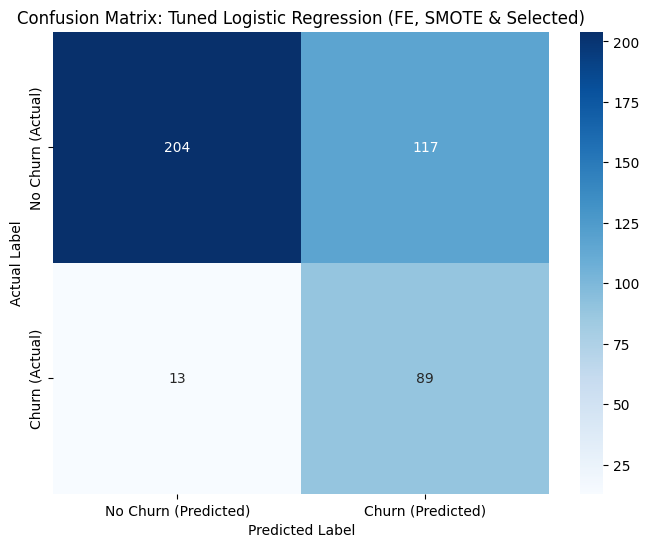

In [54]:
from sklearn.model_selection import GridSearchCV
param_grid_lr = {
    'solver': ['liblinear', 'saga'],
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=57),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_lr.fit(x_train_res, y_train_res)

print("\nBest parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score (cross-validated) for Logistic Regression:", grid_search_lr.best_score_)

best_lr_model = grid_search_lr.best_estimator_

y_pred_best_lr = best_lr_model.predict(x_test_selected)

print("\n--- Tuned Logistic Regression Model Evaluation (with SMOTE & Selected Features) ---")
print(f"Accuracy: {accuracy_score(y_test_processed, y_pred_best_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_best_lr))

conf_matrix_best_lr = confusion_matrix(y_test_processed, y_pred_best_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix: Tuned Logistic Regression (FE, SMOTE & Selected)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 100}
Best F1-score (cross-validated) for Random Forest: 0.8488676346437384

--- Tuned Random Forest Classifier Evaluation (with SMOTE & Selected Features) ---
Accuracy: 0.7707

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       321
           1       0.52      0.66      0.58       102

    accuracy                           0.77       423
   macro avg       0.70      0.73      0.71       423
weighted avg       0.79      0.77      0.78       423



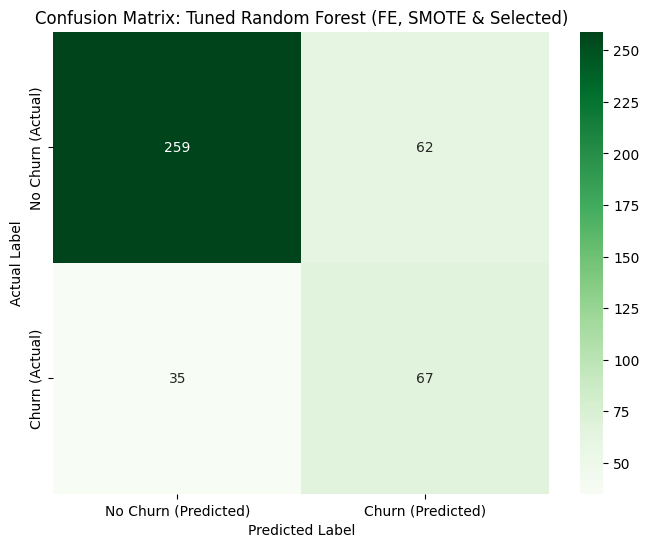

In [56]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=57),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_rf.fit(x_train_res, y_train_res)

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best F1-score (cross-validated) for Random Forest:", grid_search_rf.best_score_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(x_test_selected)

print("\n--- Tuned Random Forest Classifier Evaluation (with SMOTE & Selected Features) ---")
print(f"Accuracy: {accuracy_score(y_test_processed, y_pred_best_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_best_rf))
conf_matrix_best_rf = confusion_matrix(y_test_processed, y_pred_best_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],

            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix: Tuned Random Forest (FE, SMOTE & Selected)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [57]:
from sklearn.metrics import recall_score, f1_score

model_names_tuned = [
    'Initial Logistic Regression',
    'Initial Random Forest',
    'Initial Gradient Boosting',
    'Tuned Logistic Regression (SMOTE)',
    'Tuned Random Forest (SMOTE)'
]
predictions_tuned = [
    y_pred_log_fe,
    y_pred_rf_fe,
    y_pred_gbc_fe,
    y_pred_best_lr,
    y_pred_best_rf
]

results_tuned = {
    'Model': [],
    'Accuracy': [],
    'Recall (Churn)': [],
    'F1-Score (Churn)': []
}

for i, model_name in enumerate(model_names_tuned):
    results_tuned['Model'].append(model_name)
    results_tuned['Accuracy'].append(accuracy_score(y_test_processed, predictions_tuned[i]))
    results_tuned['Recall (Churn)'].append(recall_score(y_test_processed, predictions_tuned[i], pos_label=1))
    results_tuned['F1-Score (Churn)'].append(f1_score(y_test_processed, predictions_tuned[i], pos_label=1))

results_tuned_df = pd.DataFrame(results_tuned)
display(results_tuned_df.sort_values(by='F1-Score (Churn)', ascending=False))

,Model,Accuracy,Recall (Churn),F1-Score (Churn)
4,Tuned Random Forest (SMOTE),0.770686,0.656863,0.580087
3,Tuned Logistic Regression (SMOTE),0.692671,0.872549,0.577922
0,Initial Logistic Regression,0.801418,0.529412,0.562500
1,Initial Random Forest,0.796690,0.529412,0.556701
2,Initial Gradient Boosting,0.791962,0.509804,0.541667


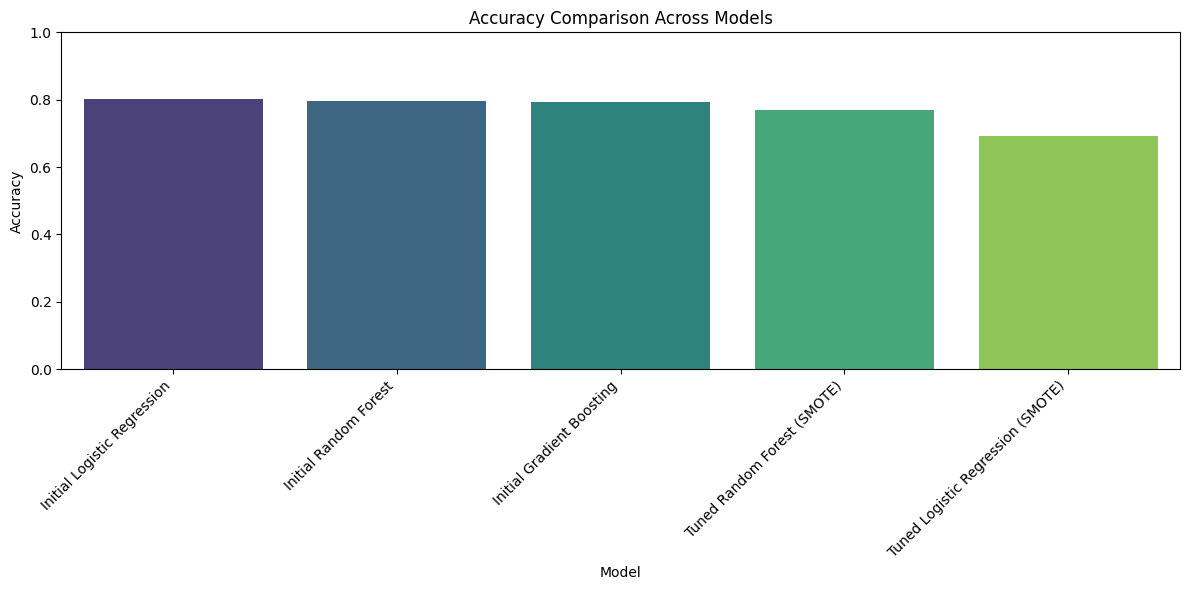

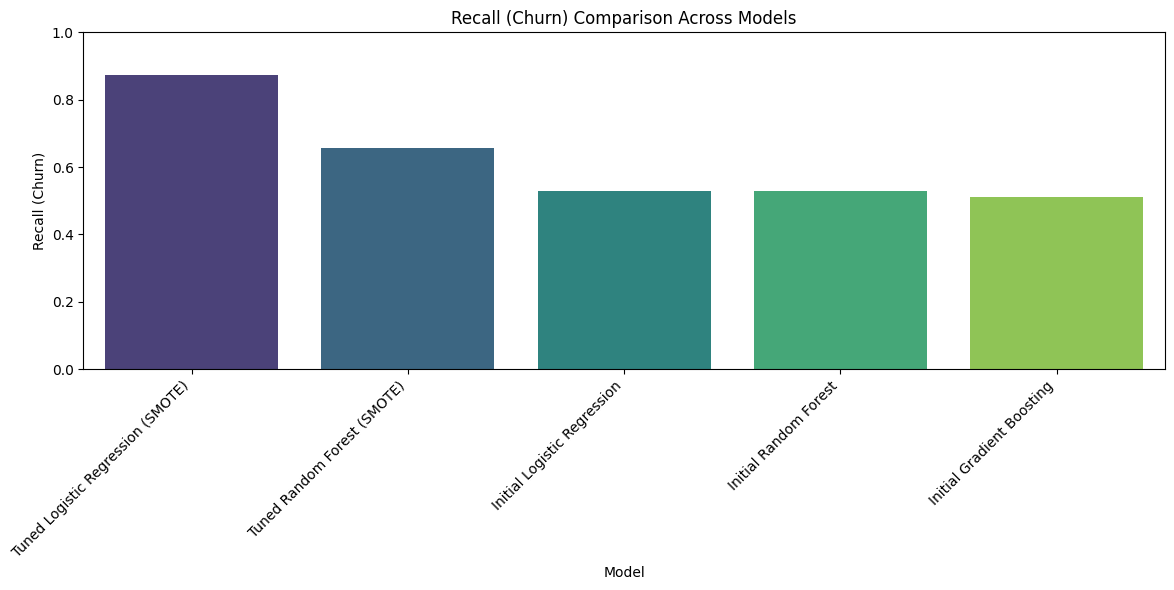

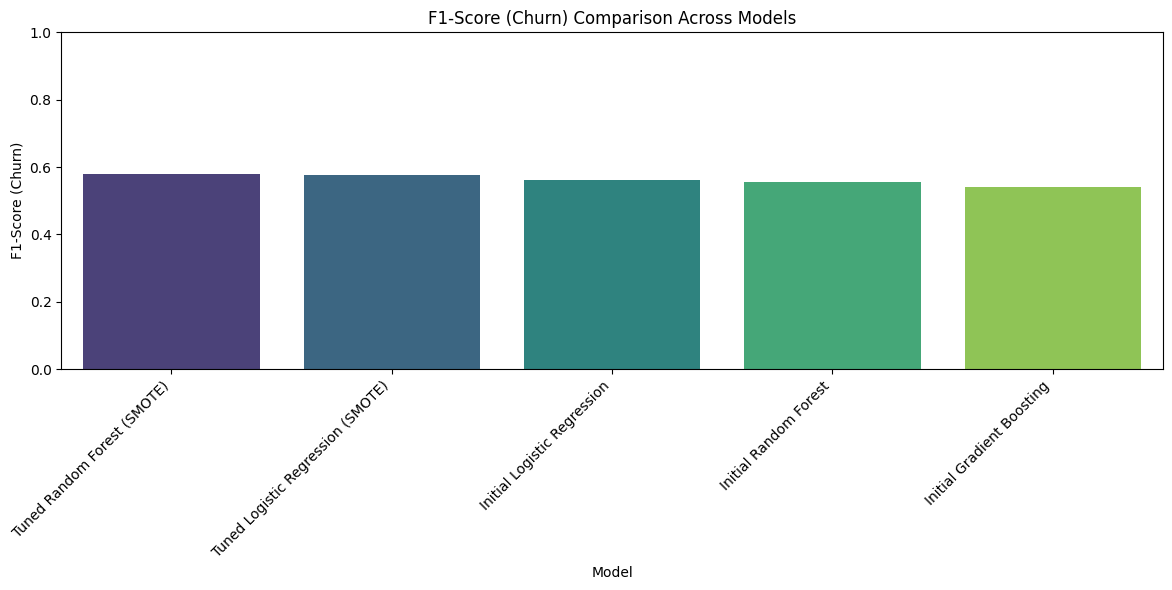

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
metrics = ['Accuracy', 'Recall (Churn)', 'F1-Score (Churn)']

for metric in metrics:
    fig = plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y=metric, hue='Model', data=results_tuned_df.sort_values(by=metric, ascending=False), palette='viridis', legend=False)
    plt.title(f'{metric} Comparison Across Models')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [61]:
new_data = data_initial.copy()
new_data_for_prediction = new_data.copy()
new_data_for_prediction['TotalCharges'] = pd.to_numeric(new_data_for_prediction['TotalCharges'], errors='coerce').fillna(0)

if 'customerID' in new_data_for_prediction.columns:
    new_data_for_prediction.drop(columns=['customerID'], inplace=True)
new_data_encoded = pd.get_dummies(new_data_for_prediction, columns=categorical_cols, drop_first=True, dtype=int)
missing_in_new_encoded = set(train_cols) - set(new_data_encoded.columns)
for c in missing_in_new_encoded:
    new_data_encoded[c] = 0

extra_in_new_encoded = set(new_data_encoded.columns) - set(train_cols)
for c in extra_in_new_encoded:
    new_data_encoded.drop(columns=[c], inplace=True)
new_data_aligned = new_data_encoded[train_cols]
new_data_scaled = std_scalar.transform(new_data_aligned)
new_data_processed_scaled_df = pd.DataFrame(new_data_scaled, columns=train_cols, index=new_data_for_prediction.index)

new_data_processed_scaled_df['Tenure_x_Contract'] = new_data_processed_scaled_df['tenure'] * new_data_processed_scaled_df['Contract_Two year']
new_data_processed_scaled_df['Tenure_x_MonthlyCharges'] = new_data_processed_scaled_df['tenure'] * new_data_processed_scaled_df['MonthlyCharges']

final_new_data_features = new_data_processed_scaled_df[selected_features]

print("\nProcessed new_data head (with selected features):")
display(final_new_data_features.head())
print("\nProcessed new_data shape:", final_new_data_features.shape)


Processed new_data head (with selected features):


,TotalCharges,Tenure_x_MonthlyCharges,MonthlyCharges,tenure,Tenure_x_Contract,PaymentMethod_Electronic check,InternetService_Fiber optic,PaperlessBilling_Yes,OnlineSecurity_Yes,gender_Male,Contract_Two year,Partner_Yes,TechSupport_Yes,StreamingTV_Yes,Dependents_Yes
0,0.454423,0.195598,0.558290,0.350353,-0.185561,1.413139,1.139460,0.841926,-0.634477,-1.026726,-0.529641,1.045666,-0.645497,-0.764990,1.497805
1,-0.606756,-0.378792,0.480050,-0.789067,0.417922,1.413139,-0.877609,-1.187753,1.576102,-1.026726,-0.529641,1.045666,-0.645497,1.307207,-0.667643
2,0.858261,0.559459,1.184208,0.472433,-0.250220,1.413139,1.139460,0.841926,-0.634477,-1.026726,-0.529641,-0.956328,1.549193,1.307207,-0.667643
3,2.762940,2.958308,1.790151,1.652547,3.120127,1.413139,1.139460,0.841926,1.576102,-1.026726,1.888072,-0.956328,1.549193,1.307207,-0.667643
4,-0.827620,0.816708,-0.938255,-0.870454,0.461028,1.413139,-0.877609,-1.187753,-0.634477,-1.026726,-0.529641,-0.956328,1.549193,-0.764990,-0.667643



Processed new_data shape: (1409, 15)


In [63]:
predictions_on_new_data = best_lr_model.predict(final_new_data_features)
churn_predictions_mapped = pd.Series(predictions_on_new_data).map({1: 'Yes', 0: 'No'})

print("\nChurn Predictions for the New Data (first 10):")
display(churn_predictions_mapped.head(10))

print("\nDistribution of Predicted Churn:")
display(churn_predictions_mapped.value_counts())


Churn Predictions for the New Data (first 10):


,0
0,Yes
1,Yes
2,Yes
3,No
4,Yes
5,Yes
6,No
7,No
8,No
9,No



Distribution of Predicted Churn:


,count
Yes,714
No,695
